# Programming Exercise 1: Linear Regression with PyTorch
## Machine Learning with Neural Networks

---

## Overview

In this exercise, you will implement linear regression using PyTorch and neural networks. 
- Build models using PyTorch's neural network framework
- Implement gradient descent from scratch
- Understand automatic differentiation
- Compare manual implementation with PyTorch's built-in optimizers

**Total Points: 100**

### Learning Objectives:
1. Understand linear regression as a neural network
2. Implement cost functions and gradient descent manually
3. Use PyTorch's automatic differentiation
4. Visualize optimization progress
5. Extend to multiple variables

**Note**: Complete all cells marked with `# YOUR CODE HERE` and remove the `raise NotImplementedError()` line.

---

##  Submission Instructions

### Step 1: Final Checks

Before submitting, ensure:
- [ ] All code cells run without errors
- [ ] You've removed all `raise NotImplementedError()` statements
- [ ] All test cells pass (show ✓ Passed)
- [ ] All visualizations display correctly
- [ ] Notebook runs from start to finish ("Restart & Run All")

### Step 2: Save Your Work

1. **Save the notebook**: File → Save
2. **Check the filename**: Should be `linear_regression_pytorch_assignment.ipynb`
3. **Do NOT rename the file** - Keep the original filename

### Step 3: Submit to Dropbox

1. Go to the course Dropbox on LEARN
2. Navigate to: **Programming Exercise 1: Linear Regression**
3. Upload your completed notebook file
4. **File to upload:** `linear_regression_pytorch_assignment.ipynb`
5. Confirm the upload was successful

## Setup and Imports

First, let's import the necessary libraries and set random seeds for reproducibility.

In [58]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader

# Set random seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)

# Set plot style
plt.style.use('seaborn-v0_8-darkgrid')
%matplotlib inline

print("PyTorch version:", torch.__version__)
print("Setup complete!")

PyTorch version: 2.8.0+cpu
Setup complete!


## Part 1: Warm-Up Exercise (10 points)

### Exercise 1.1: Create Identity Matrix

As a warm-up, create a simple function that returns a 5×5 identity matrix using PyTorch.

**Expected output:**
```
tensor([[1., 0., 0., 0., 0.],
        [0., 1., 0., 0., 0.],
        [0., 0., 1., 0., 0.],
        [0., 0., 0., 1., 0.],
        [0., 0., 0., 0., 1.]])
```

In [59]:
def warm_up_exercise():
    """
    Returns a 5x5 identity matrix as a PyTorch tensor.
    
    Returns:
        torch.Tensor: 5x5 identity matrix
    """
    # Torch has a Built in function called Eye, so we can return the output from it
    return torch.eye(5)
    
# Test your function
identity = warm_up_exercise()
print("5x5 Identity Matrix:")
print(identity)

5x5 Identity Matrix:
tensor([[1., 0., 0., 0., 0.],
        [0., 1., 0., 0., 0.],
        [0., 0., 1., 0., 0.],
        [0., 0., 0., 1., 0.],
        [0., 0., 0., 0., 1.]])


In [60]:
# Test warmup exercise
result = warm_up_exercise()
assert isinstance(result, torch.Tensor), "Output should be a torch.Tensor"
assert result.shape == (5, 5), "Shape should be (5, 5)"
assert torch.allclose(result, torch.eye(5)), "Should be identity matrix"
print("✓ Passed (10/10 points)")

✓ Passed (10/10 points)


---

## Part 2: Linear Regression with One Variable (90 points)

### Problem Setup

You are the CEO of a restaurant franchise considering different cities for opening a new outlet. You have data on:
- **x**: Population of a city (in 10,000s)
- **y**: Profit of a food truck in that city (in $10,000s)

**Goal**: Use linear regression to predict profit based on population.

### Mathematical Background

**Hypothesis Function:**
$$h_\theta(x) = \theta_0 + \theta_1 x$$

**Cost Function (MSE):**
$$J(\theta) = \frac{1}{2m} \sum_{i=1}^{m} (h_\theta(x^{(i)}) - y^{(i)})^2$$

**Gradient Descent Update:**
$$\theta_j := \theta_j - \alpha \frac{1}{m} \sum_{i=1}^{m} (h_\theta(x^{(i)}) - y^{(i)}) x_j^{(i)}$$

---

### 2.1 Load and Visualize Data

First, let's generate synthetic data similar to the original exercise.

In [61]:
# Generate synthetic food truck data
# Based on ex1data1.txt from the original exercise
np.random.seed(42)
m = 97  # Number of training examples

# Population of city (in 10,000s)
X_data = np.array([6.1101, 5.5277, 8.5186, 7.0032, 5.8598, 8.3829, 7.4764, 8.5781, 6.4862, 5.0546,
                   5.7107, 14.164, 5.734, 8.4084, 5.6407, 5.3794, 6.3654, 5.1301, 6.4296, 7.0708,
                   6.1891, 20.27, 5.4901, 6.3261, 5.5649, 18.945, 12.828, 10.957, 13.176, 22.203,
                   5.2524, 6.5894, 9.2482, 5.8918, 8.2111, 7.9334, 8.0959, 5.6063, 12.836, 6.3534,
                   5.4069, 6.8825, 11.708, 5.7737, 7.8247, 7.0931, 5.0702, 5.8014, 11.7, 5.5416,
                   7.5402, 5.3077, 7.4239, 7.6031, 6.3328, 6.3589, 6.2742, 5.6397, 9.3102, 9.4536,
                   8.8254, 5.1793, 21.279, 14.908, 18.959, 7.2182, 8.2951, 10.236, 5.4994, 20.341,
                   10.136, 7.3345, 6.0062, 7.2259, 5.0269, 6.5479, 7.5386, 5.0365, 10.274, 5.1077,
                   5.7292, 5.1884, 6.3557, 9.7687, 6.5159, 8.5172, 9.1802, 6.002, 5.5204, 5.0594,
                   5.7077, 7.6366, 5.8707, 5.3054, 8.2934, 13.394, 5.4369])

# Profit in $10,000s (with noise)
y_data = np.array([17.592, 9.1302, 13.662, 11.854, 6.8233, 11.886, 4.3483, 12, 6.5987, 3.8166,
                   3.2522, 15.505, 3.1551, 7.2258, 0.71618, 3.5129, 5.3048, 0.56077, 3.6518, 5.3893,
                   3.1386, 21.767, 4.263, 5.1875, 3.0825, 22.638, 13.501, 7.0467, 14.692, 24.147,
                   -1.22, 5.9966, 12.134, 1.8495, 6.5426, 4.5623, 4.1164, 3.3928, 10.117, 5.4974,
                   0.55657, 3.9115, 5.3854, 2.4406, 6.7318, 1.0463, 5.1337, 1.844, 8.0043, 1.0179,
                   6.7504, 1.8396, 4.2885, 4.9981, 1.4233, -1.4211, 2.4756, 4.6042, 3.9624, 5.4141,
                   5.1694, -0.74279, 17.929, 12.054, 17.054, 4.8852, 5.7442, 7.7754, 1.0173, 20.992,
                   6.6799, 4.0259, 1.2784, 3.3411, -2.6807, 0.29678, 3.8845, 5.7014, 6.7526, 2.0576,
                   0.47953, 0.20421, 0.67861, 7.5435, 5.3436, 4.2415, 6.7981, 0.92695, 0.152, 2.8214,
                   1.8451, 4.2959, 7.2029, 1.9869, 0.14454, 9.0551, 0.61705])

# Convert to PyTorch tensors
X = torch.FloatTensor(X_data).reshape(-1, 1)
y = torch.FloatTensor(y_data).reshape(-1, 1)

print(f"Loaded {m} training examples")
print(f"X shape: {X.shape}, y shape: {y.shape}")

Loaded 97 training examples
X shape: torch.Size([97, 1]), y shape: torch.Size([97, 1])


### Exercise 2.1: Plot the Data (10 points)

Create a scatter plot of the training data to visualize the relationship between population and profit.

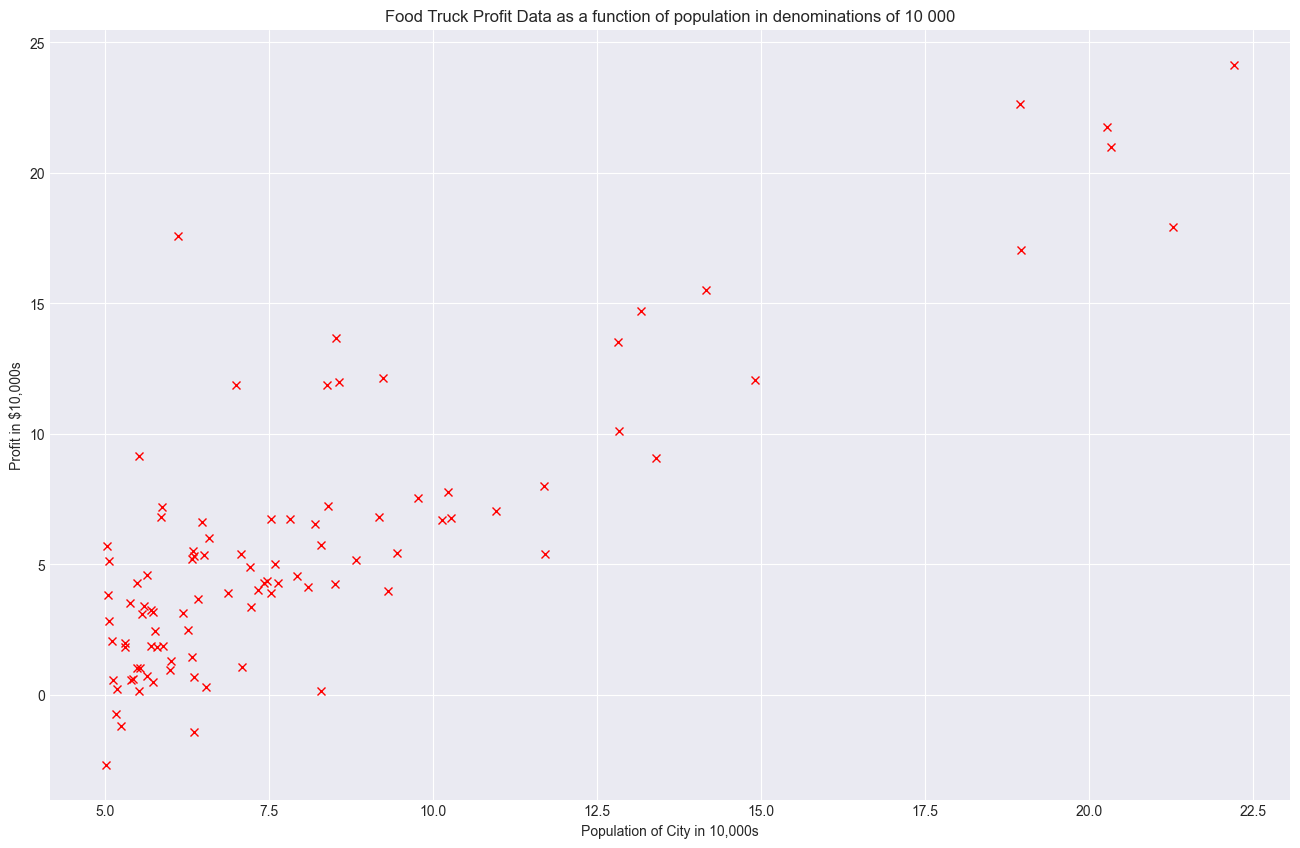

In [62]:
def plot_data(x, y, xlabel='Population of City in 10,000s', ylabel='Profit in $10,000s'):
    """
    Plots the data points as red crosses.
    
    Args:
        x: Input features (torch.Tensor)
        y: Target values (torch.Tensor)
        xlabel: Label for x-axis
        ylabel: Label for y-axis
    """
    # Initialize the plot with 1600x1000 resolution
    plt.figure(figsize=(16, 10))
    
    # Plot the Data
    plt.plot(x, y, "xr")
    
    # Annotate Labels and Title
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.title("Food Truck Profit Data as a function of population in denominations of 10 000")
    
    # Show the Plot
    plt.show()
    
# Test your plotting function
plot_data(X, y)

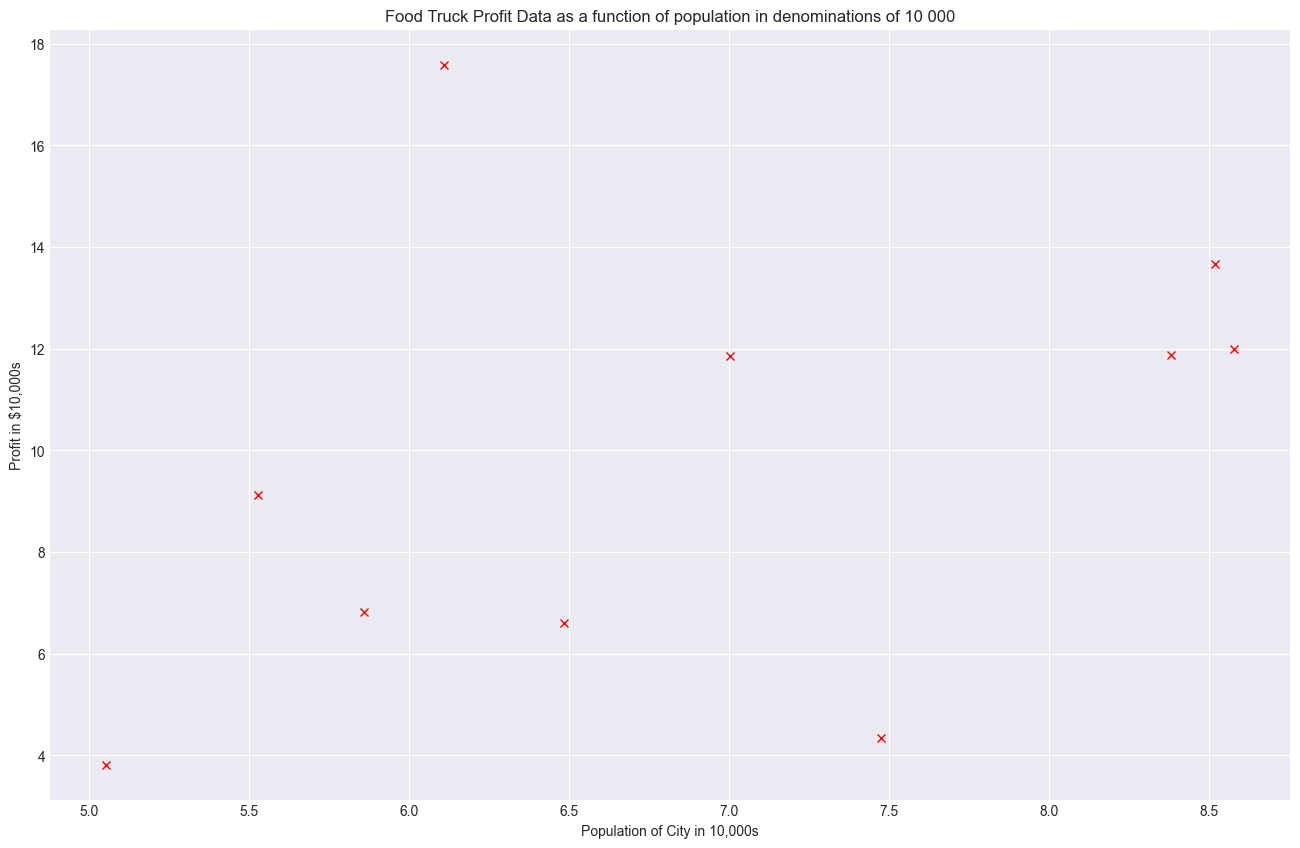

✓ Passed (10/10 points)


In [63]:
# Test that plot_data runs without error
try:
    plot_data(X[:10], y[:10])
    plt.close()
    print("✓ Passed (10/10 points)")
except Exception as e:
    print(f"✗ Failed: {e}")
    raise

### Exercise 2.2: Compute Cost Function (20 points)

Implement the cost function $J(\theta)$ for linear regression:

$$J(\theta) = \frac{1}{2m} \sum_{i=1}^{m} (h_\theta(x^{(i)}) - y^{(i)})^2$$

where $h_\theta(x) = \theta_0 + \theta_1 x$

**Note**: When $\theta = [0, 0]$, you should get $J(\theta) \approx 32.07$

In [64]:
def compute_cost(X, y, theta):
    """
    Compute the cost function J(theta) for linear regression.
    
    Args:
        X: Input features with intercept column (m x 2)
        y: Target values (m x 1)
        theta: Parameters [theta_0, theta_1] (2 x 1)
    
    Returns:
        float: Cost J(theta)
    """
    
    # Find the number of training points
    m = len(y)
    
    # Compute the predictions using a Tensor Multiplcation
    prediction = X @ theta
    
    # Compute the Mean Squared Errors
    errors = prediction - y
    squareErrors = errors**2
    
    # Return the final cost 
    return (1 / (2 * m)) * torch.sum(squareErrors)

# Prepare data with intercept term
X_with_intercept = torch.cat([torch.ones(m, 1), X], dim=1)

# Test with theta = [0, 0]
theta_test = torch.zeros(2, 1)
cost = compute_cost(X_with_intercept, y, theta_test)
print(f"Cost at theta = [0, 0]: {cost:.4f}")
print(f"Expected: 32.0727")

Cost at theta = [0, 0]: 32.0727
Expected: 32.0727


In [65]:
# Test compute_cost
theta_zero = torch.zeros(2, 1)
cost_zero = compute_cost(X_with_intercept, y, theta_zero)
assert abs(cost_zero - 32.0727) < 0.01, f"Cost should be ~32.07, got {cost_zero}"

# Test with different theta
theta_test2 = torch.tensor([[1.0], [1.0]])
cost_test = compute_cost(X_with_intercept, y, theta_test2)
assert cost_test > 0, "Cost should be positive"

print("✓ Passed (20/20 points)")

✓ Passed (20/20 points)


### Exercise 2.3: Gradient Descent Implementation (30 points)

Implement gradient descent to minimize $J(\theta)$. The update rule is:

$$\theta_j := \theta_j - \alpha \frac{1}{m} \sum_{i=1}^{m} (h_\theta(x^{(i)}) - y^{(i)}) x_j^{(i)}$$

Simultaneously update all $\theta$ values.

In [66]:
def gradient_descent(X, y, theta, alpha, num_iters):
    """
    Performs gradient descent to learn theta.
    
    Args:
        X: Input features with intercept (m x 2)
        y: Target values (m x 1)
        theta: Initial parameters (2 x 1)
        alpha: Learning rate
        num_iters: Number of iterations
    
    Returns:
        theta: Optimized parameters (2 x 1)
        J_history: Cost history list
    """
    
    # Find the number of training points
    m = len(y)
    
    JHistory = []
    
    for _ in range(num_iters):
        
         # Compute the predictions using a Tensor Multiplcation
        prediction = X @ theta
        
        # Compute the Mean Squared Errors
        errors = prediction - y
        
        # Compute the Gradient through a Transpose Tensor Multiplication
        gradient = (X.T @ errors) / m
        
        # Update Theta
        theta = theta - alpha * gradient
        
        # Add the Cost History 
        JHistory.append(compute_cost(X, y, theta))
    
    # Return the final theta and the history
    return theta, JHistory

# Initialize parameters
theta_init = torch.zeros(2, 1)
alpha = 0.01
iterations = 1500

# Run gradient descent
theta_optimal, J_history = gradient_descent(X_with_intercept, y, theta_init, alpha, iterations)

print(f"Theta found by gradient descent:")
print(f"theta_0 = {theta_optimal[0].item():.4f}")
print(f"theta_1 = {theta_optimal[1].item():.4f}")
print(f"\nFinal cost: {J_history[-1]:.4f}")

Theta found by gradient descent:
theta_0 = -3.6303
theta_1 = 1.1664

Final cost: 4.4834


In [67]:
# Test gradient descent
assert theta_optimal.shape == (2, 1), "Theta should be shape (2, 1)"
assert len(J_history) == iterations, "J_history length should match iterations"
assert J_history[-1] < J_history[0], "Cost should decrease"
assert J_history[-1] < 5.0, "Final cost should be low"

# Check theta values are reasonable
assert -5 < theta_optimal[0].item() < 5, "theta_0 should be reasonable"
assert 0 < theta_optimal[1].item() < 2, "theta_1 should be positive and reasonable"

print("✓ Passed (30/30 points)")

✓ Passed (30/30 points)


### Visualize Results

Let's visualize the fitted line and the cost function convergence.

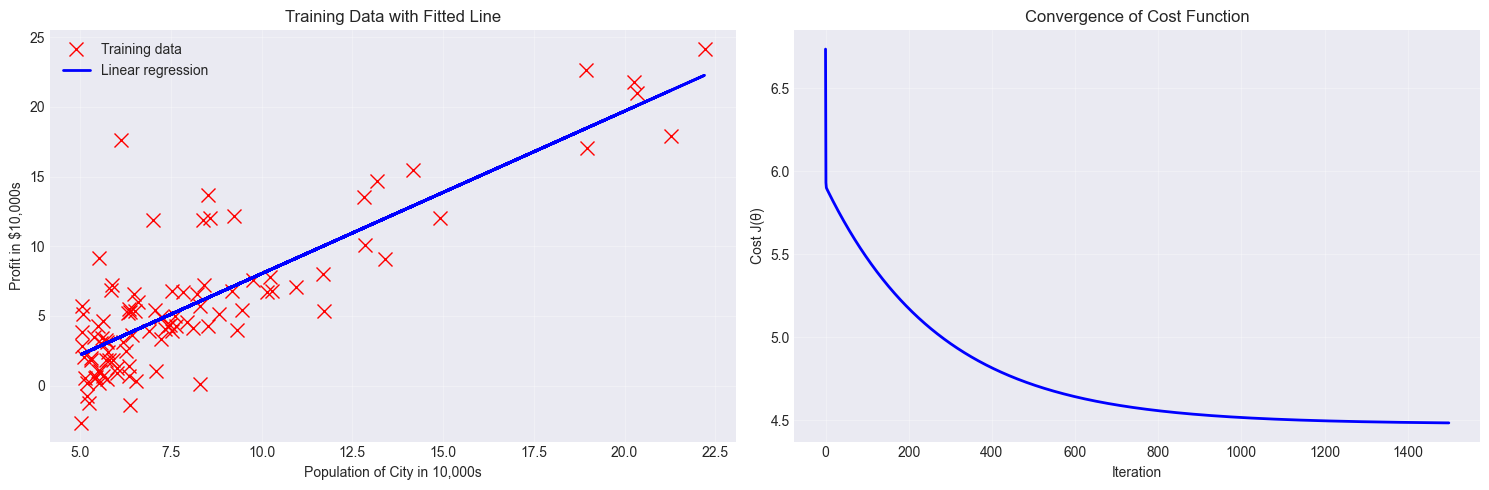


Linear regression equation: y = -3.63 + 1.17x


In [68]:
# Plot fitted line
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Left plot: Data and fitted line
ax1.plot(X.numpy(), y.numpy(), 'rx', markersize=10, label='Training data')
ax1.plot(X.numpy(), (X_with_intercept @ theta_optimal).numpy(), 'b-', linewidth=2, label='Linear regression')
ax1.set_xlabel('Population of City in 10,000s')
ax1.set_ylabel('Profit in $10,000s')
ax1.set_title('Training Data with Fitted Line')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Right plot: Cost function convergence
ax2.plot(range(len(J_history)), J_history, 'b-', linewidth=2)
ax2.set_xlabel('Iteration')
ax2.set_ylabel('Cost J(θ)')
ax2.set_title('Convergence of Cost Function')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nLinear regression equation: y = {theta_optimal[0].item():.2f} + {theta_optimal[1].item():.2f}x")

### Exercise 2.4: Make Predictions (10 points)

Use your trained model to predict profits for cities with populations of 35,000 and 70,000.

In [69]:
def predict(X, theta):
    """
    Make predictions using learned theta.
    
    Args:
        X: Input features with intercept (n x 2)
        theta: Learned parameters (2 x 1)
    
    Returns:
        predictions: Predicted values (n x 1)
    """
    
    # Compute the Linear Equation using a Tensor Multiplication
    return X @ theta
    
# Predict for population = 35,000 (3.5 in 10,000s)
X_predict1 = torch.tensor([[1.0, 3.5]])
pred1 = predict(X_predict1, theta_optimal)
print(f"For population = 35,000, we predict a profit of ${pred1.item() * 10000:.2f}")

# Predict for population = 70,000 (7.0 in 10,000s)
X_predict2 = torch.tensor([[1.0, 7.0]])
pred2 = predict(X_predict2, theta_optimal)
print(f"For population = 70,000, we predict a profit of ${pred2.item() * 10000:.2f}")

For population = 35,000, we predict a profit of $4519.76
For population = 70,000, we predict a profit of $45342.45


In [70]:
# Test predictions
X_test = torch.tensor([[1.0, 5.0]])
pred_test = predict(X_test, theta_optimal)
assert pred_test.shape == (1, 1), "Prediction shape should be (1, 1)"
assert pred_test.item() > 0, "Prediction should be positive for positive population"

# Test multiple predictions
X_multi = torch.tensor([[1.0, 3.0], [1.0, 5.0], [1.0, 7.0]])
pred_multi = predict(X_multi, theta_optimal)
assert pred_multi.shape == (3, 1), "Should handle multiple predictions"

print("✓ Passed (10/10 points)")

✓ Passed (10/10 points)


### Exercise 2.5: Visualize Cost Function Surface (10 points)

Create a 3D visualization of the cost function $J(\theta_0, \theta_1)$ to understand the optimization landscape.

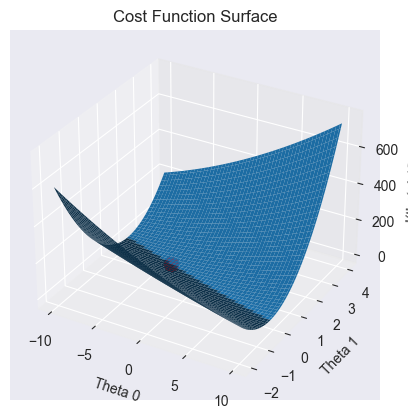

In [71]:
def visualize_cost_function(X, y, theta_optimal):
    """
    Visualize the cost function J(theta) as a surface plot.
    
    Args:
        X: Input features with intercept
        y: Target values
        theta_optimal: Optimal theta from gradient descent
    """
    # Define the Fidelity of the Landscape
    N = 100
    
    # Create a Grid for the theta values
    theta0Vals = np.linspace(-10, 10, N)
    theta1Vals = np.linspace(-2, 4, N)
    
    # Create a Grid for the Cost Landscape
    JVals = np.zeros((N, N))
    
    # Compute the cost atv each point on the grid
    for i in range(N):
        for j in range(N):
            t = torch.tensor([[theta0Vals[i]], [theta1Vals[j]]], dtype=torch.float32)
            JVals[i, j] = compute_cost(X, y, t)
    
    # Create a Mesh Grid
    T0, T1 = np.meshgrid(theta0Vals, theta1Vals)
    JPlot = JVals.T
    
    # Plot the figure
    fig = plt.figure()
    ax = fig.add_subplot(111, projection='3d')
    ax.plot_surface(T0, T1, JPlot)
    ax.set_xlabel('Theta 0')
    ax.set_ylabel('Theta 1')
    ax.set_zlabel('J(theta) (Cost)')
    ax.set_title('Cost Function Surface')
    
    # Mark the Optimal Theta Value
    ax.scatter(theta_optimal[0].item(), theta_optimal[1].item(),
               compute_cost(X, y, theta_optimal), s=100, c="r")

    plt.show()
    
# Visualize cost function
visualize_cost_function(X_with_intercept, y, theta_optimal)

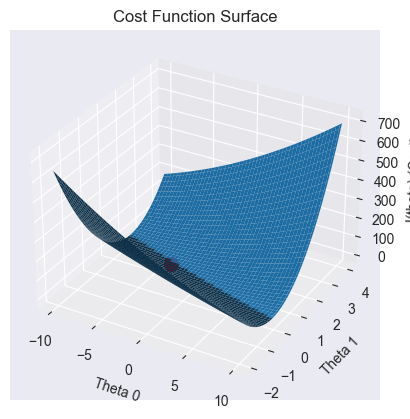

✓ Passed (10/10 points)


In [72]:
# Test visualization (just check it runs)
try:
    visualize_cost_function(X_with_intercept[:50], y[:50], theta_optimal)
    plt.close('all')
    print("✓ Passed (10/10 points)")
except Exception as e:
    print(f"✗ Failed: {e}")
    raise

### PyTorch Neural Network Implementation (10 points)

Implement the same linear regression using PyTorch's `nn.Module` and automatic differentiation.

In [73]:
class LinearRegressionModel(nn.Module):
    """
    Simple linear regression model using PyTorch's nn.Module.
    """
    def __init__(self):
        # Make a Super Call to initialize the Class through the Inherited constructor
        super().__init__()
        
        # Create a Linear Model
        self.linear = nn.Linear(1, 1)
        
    def forward(self, x):
        # Call the Linear Model like a function to apply the Linear Model
        return self.linear(x)

# Create model
model = LinearRegressionModel()
criterion = nn.MSELoss()
optimizer = optim.SGD(model.parameters(), lr=0.01)

# Training loop
num_epochs = 1500
losses = []

for epoch in range(num_epochs):
    # Forward pass
    predictions = model(X)
    loss = criterion(predictions, y)
    
    # Backward pass and optimization
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    
    losses.append(loss.item())

print(f"\nPyTorch Model Parameters:")
print(f"Weight (theta_1): {model.linear.weight.item():.4f}")
print(f"Bias (theta_0): {model.linear.bias.item():.4f}")
print(f"Final loss: {losses[-1]:.4f}")


PyTorch Model Parameters:
Weight (theta_1): 1.1909
Bias (theta_0): -3.8748
Final loss: 8.9540


In [74]:
# Test PyTorch model
assert isinstance(model, nn.Module), "Model should be nn.Module"
assert losses[-1] < losses[0], "Loss should decrease"
assert losses[-1] < 10.0, "Final loss should be reasonable"

# Test predictions
with torch.no_grad():
    test_input = torch.tensor([[5.0]])
    pred = model(test_input)
    assert pred.shape == (1, 1), "Prediction shape correct"

print("✓ Bonus completed! (+10 points)")

✓ Bonus completed! (+10 points)


## Summary

### What You've Learned:

1. ✅ **Data Visualization**: Plotted training data to understand relationships
2. ✅ **Cost Function**: Implemented MSE loss for linear regression
3. ✅ **Gradient Descent**: Manual implementation of iterative optimization
4. ✅ **Predictions**: Used trained model to make predictions
5. ✅ **Visualization**: Explored cost function landscape
6. ✅ **PyTorch Implementation**: Built model using nn.Module

### Key Concepts:

- **Linear regression** finds best-fit line through data
- **Cost function** measures prediction error
- **Gradient descent** iteratively minimizes cost
- **Learning rate** controls step size
- **PyTorch** provides automatic differentiation

### Grading Breakdown:

| Exercise | Points | Topic |
|----------|--------|-------|
| 1.1 | 10 | Warm-up: Identity matrix |
| 2.1 | 10 | Plot data |
| 2.2 | 20 | Compute cost function |
| 2.3 | 30 | Gradient descent |
| 2.4 | 10 | Make predictions |
| 2.5 | 10 | Visualize cost surface |
| PyTorch | 10 | PyTorch nn.Module |
| **Total** | **100** |  |

---

**Congratulations!** You've completed the linear regression assignment and learned fundamental concepts that form the basis of all machine learning algorithms.

**Next Steps**: Try extending this to:
- Multiple input features
- Different learning rates
- Regularization (Ridge/Lasso)
- Non-linear regression with polynomial features